In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sanaullah313","key":"5fb0ead9dadfaef6d3368debf9736444"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
 99% 2.66G/2.70G [00:23<00:00, 139MB/s]
100% 2.70G/2.70G [00:26<00:00, 110MB/s]


In [4]:
!unzip new-plant-diseases-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/273a7a9e-18be-4b6a-976a-fa5ffd69b731___RS_HL 4366_90deg.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/275f8963-f4f4-4903-962b-1da716725d08___RS_HL 4780_90deg.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/275f8963-f4f4-4903-962b-1da716725d08___RS_HL 4780_new30degFlipLR.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/27c2aaa4-de4b-4fb1-ba8d-14d4b24b2afa___RS_HL 4665.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/27c2aaa4-de4b-4fb1-ba8d-14d4b24b2afa___RS_HL 4665_270deg.JPG  
  inflating: new plant diseases dataset(augmented)/New 

In [5]:
!ls "New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

train  valid


In [6]:
!ls

 kaggle.json				  new-plant-diseases-dataset.zip
'new plant diseases dataset(augmented)'   sample_data
'New Plant Diseases Dataset(Augmented)'   test


## Importing Libraries

In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Data Preprocessing

### Training Image Preprocessing

In [8]:
training_set = tf.keras.utils.image_dataset_from_directory(
    "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,

    verbose=True,
)

Found 70295 files belonging to 38 classes.


### Validation Image Preprocessing

In [9]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    verbose=True,
)

Found 17572 files belonging to 38 classes.


In [10]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [11]:
for x, y in training_set:
    print(x)
    print(y)
    break

tf.Tensor(
[[[[142.25 128.25 128.25]
   [135.5  121.5  121.5 ]
   [152.75 138.75 138.75]
   ...
   [156.5  144.5  148.5 ]
   [153.5  141.5  145.5 ]
   [164.   152.   156.  ]]

  [[144.25 130.25 130.25]
   [141.75 127.75 127.75]
   [155.5  141.5  141.5 ]
   ...
   [172.75 160.75 164.75]
   [141.25 129.25 133.25]
   [157.75 145.75 149.75]]

  [[151.5  137.5  137.5 ]
   [151.   137.   137.  ]
   [130.5  116.5  116.5 ]
   ...
   [139.75 127.75 131.75]
   [160.75 148.75 152.75]
   [153.25 141.25 145.25]]

  ...

  [[146.   135.   139.  ]
   [145.75 134.75 138.75]
   [139.25 128.25 132.25]
   ...
   [161.   150.   156.  ]
   [149.75 138.75 144.75]
   [154.75 143.75 149.75]]

  [[144.5  133.5  137.5 ]
   [141.25 130.25 134.25]
   [137.   126.   130.  ]
   ...
   [155.5  144.5  150.5 ]
   [148.75 137.75 143.75]
   [161.   150.   156.  ]]

  [[150.75 139.75 143.75]
   [149.75 138.75 142.75]
   [138.   127.   131.  ]
   ...
   [159.5  148.5  154.5 ]
   [160.   149.   155.  ]
   [152.   141.   14

### To avoide Overshooting
1. Choose small learning rate default 0.001 and we are taking 0.0001
2. There may be chance of Underfitting, so increase number of neuron
3. Add more Convolution layer to extract more feature from images there may be possibility that model unable to capture relevent feature or model is confusingdue to lack of feature so feed with more feature

## Building Model

In [12]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [13]:
model = Sequential()

## Building Convolution Layer

In [14]:
model.add(Conv2D(filters=32, kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32, kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.add(Conv2D(filters=64, kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64, kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [16]:
model.add(Conv2D(filters=128, kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128, kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [17]:
model.add(Conv2D(filters=256, kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256, kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [18]:
model.add(Conv2D(filters=512, kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512, kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [19]:
model.add(Dropout(0.25)) # To avoide Overfitting

In [20]:
model.add(Flatten())

In [21]:
model.add(Dense(units=1500,activation='relu'))

In [22]:
model.add(Dropout(0.4))

In [23]:
# output layer
model.add(Dense(units=38,activation='softmax'))

### Compiling Model

In [24]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',metrics=['accuracy'])

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [26]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 165s 68ms/step - accuracy: 0.3925 - loss: 2.1713 - val_accuracy: 0.8174 - val_loss: 0.5820
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 172s 60ms/step - accuracy: 0.8306 - loss: 0.5423 - val_accuracy: 0.9077 - val_loss: 0.2877
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 131s 60ms/step - accuracy: 0.9041 - loss: 0.2941 - val_accuracy: 0.9173 - val_loss: 0.2510
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 132s 60ms/step - accuracy: 0.9346 - loss: 0.2040 - val_accuracy: 0.9446 - val_loss: 0.1740
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 131s 60ms/step - accuracy: 0.9544 - loss: 0.1417 - val_accuracy: 0.9503 - val_loss: 0.1534
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 142s 60ms/step - accuracy: 0.9624 - loss: 0.1123 - val_accuracy: 0.9621 - val_loss: 0.1225
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 131s 60ms/step - accuracy: 0.9690 - loss: 0.0932 - val_accuracy: 0.9602 - val_loss: 0.1312
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 131s 60ms/step - accuracy: 

In [27]:
# model evaluation on training set
train_loss, train_acc = model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 50s 22ms/step - accuracy: 0.9905 - loss: 0.0290


In [28]:
print(train_loss,train_acc)

0.02585938759148121 0.9916636943817139


In [29]:
# model on validation set
val_loss, val_acc = model.evaluate(validation_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9632 - loss: 0.1222


In [30]:
print(val_loss,val_acc)

0.11993519216775894 0.9650580286979675


In [31]:
model.save("trained_model.keras")

In [32]:
model.save('trained_model.h5')

In [33]:
training_history.history

{'accuracy': [0.595689594745636,
  0.852265477180481,
  0.9123977422714233,
  0.9405932426452637,
  0.9573511481285095,
  0.9651326537132263,
  0.9704388380050659,
  0.9760153889656067,
  0.9792730808258057,
  0.9807098507881165],
 'loss': [1.380937099456787,
  0.46662434935569763,
  0.2700434625148773,
  0.18548081815242767,
  0.1344565898180008,
  0.10573416948318481,
  0.08761738240718842,
  0.0738140344619751,
  0.06266611814498901,
  0.05971329286694527],
 'val_accuracy': [0.8174368143081665,
  0.9076940417289734,
  0.9172547459602356,
  0.9446278214454651,
  0.9502617716789246,
  0.9620987772941589,
  0.9601638913154602,
  0.9660823941230774,
  0.9479854106903076,
  0.9650580286979675],
 'val_loss': [0.582032322883606,
  0.2877211570739746,
  0.25100839138031006,
  0.17402903735637665,
  0.1533963829278946,
  0.1224762350320816,
  0.13123075664043427,
  0.10906211286783218,
  0.17211061716079712,
  0.11993525177240372]}

In [34]:
# Recording History in json
import json
with open('training_his.json','w') as f:
    json.dump(training_history.history,f)

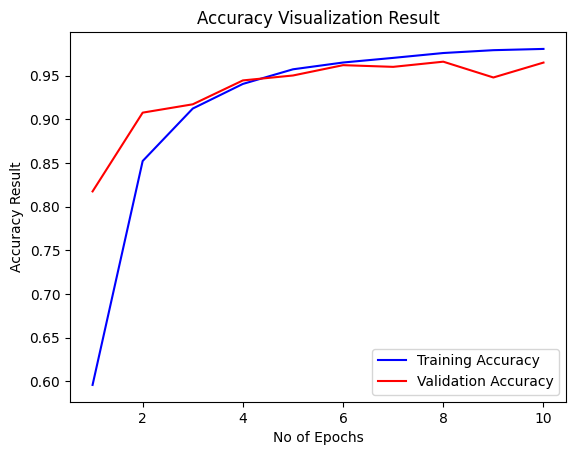

In [35]:
import matplotlib.pyplot as plt

epochs = [i for i in range(1, 11)]

plt.plot(epochs, training_history.history['accuracy'], color='blue', label='Training Accuracy')
plt.plot(epochs, training_history.history['val_accuracy'], color='red', label='Validation Accuracy')

plt.xlabel("No of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Accuracy Visualization Result")

plt.legend()
plt.show()

In [ ]:
### Some other metrics for model evaluation

In [36]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [37]:
test_set = tf.keras.utils.image_dataset_from_directory(
    "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    verbose=True,
)

Found 17572 files belonging to 38 classes.


In [38]:
y_pred = model.predict(test_set)
y_pred

550/550 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step


array([[1.0000000e+00, 6.3991493e-11, 6.6591345e-13, ..., 1.1700815e-16,
        2.3939717e-18, 3.0918698e-16],
       [9.9998271e-01, 3.8024655e-07, 1.4622423e-10, ..., 9.1496715e-12,
        1.2319286e-13, 1.1599319e-11],
       [1.0000000e+00, 4.0334458e-11, 2.6190433e-14, ..., 1.8196326e-19,
        1.7773317e-19, 1.7072973e-16],
       ...,
       [4.0384789e-09, 9.2417268e-11, 3.2732007e-08, ..., 2.9735517e-10,
        6.9467343e-10, 9.9995279e-01],
       [2.0197542e-12, 1.3738545e-13, 1.0775213e-11, ..., 8.0384419e-13,
        5.2948180e-12, 1.0000000e+00],
       [4.9120901e-19, 7.7634954e-19, 3.4016246e-18, ..., 5.7938619e-20,
        1.7211417e-15, 1.0000000e+00]], dtype=float32)

In [39]:
predicted_categories = tf.argmax(y_pred,axis=1)
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [41]:
true_categories = tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [42]:
Y_true = tf.argmax(true_categories,axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [43]:
from sklearn.metrics import classification_report,confusion_matrix

In [44]:
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.97      0.96      0.97       504
                                 Apple___Black_rot       0.97      1.00      0.99       497
                          Apple___Cedar_apple_rust       0.99      0.94      0.96       440
                                   Apple___healthy       0.98      0.95      0.96       502
                               Blueberry___healthy       0.98      0.97      0.97       454
          Cherry_(including_sour)___Powdery_mildew       0.99      1.00      0.99       421
                 Cherry_(including_sour)___healthy       1.00      0.98      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.93      0.90      0.92       410
                       Corn_(maize)___Common_rust_       0.99      1.00      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.93      0.97      0.

In [45]:
cm = confusion_matrix(Y_true,predicted_categories)
cm

array([[486,   7,   0, ...,   0,   0,   0],
       [  0, 496,   0, ...,   0,   0,   0],
       [  0,   1, 413, ...,   0,   0,   1],
       ...,
       [  0,   0,   0, ..., 482,   0,   0],
       [  0,   0,   0, ...,   0, 445,   0],
       [  0,   0,   0, ...,   0,   0, 477]])

Confusion Matrix **Visualization**

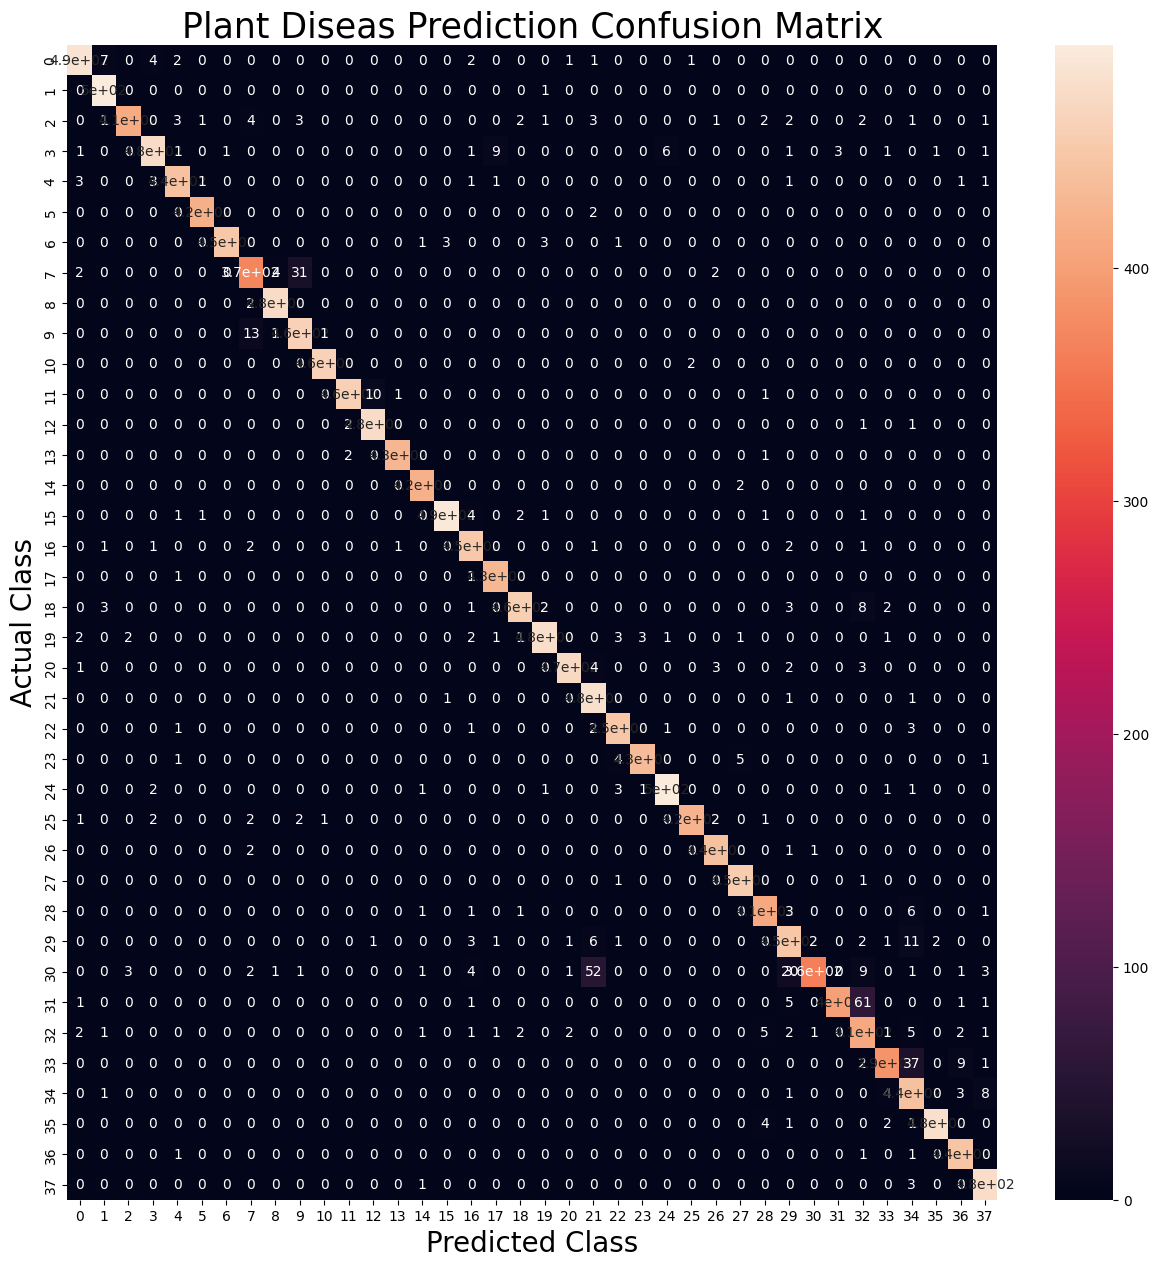

In [48]:
plt.figure(figsize=(15,15))
sns.heatmap(cm,annot=True,annot_kws={'size':10})
plt.xlabel('Predicted Class',fontsize=20)
plt.ylabel('Actual Class',fontsize=20)
plt.title('Plant Diseas Prediction Confusion Matrix',fontsize=25)
plt.show()